In [1]:
import numpy as np
import autograd.numpy as anp
from autograd import hessian


n, d, k, tau = 4, 3, 2, 100 
diagonal_elements = [1,1]
matrix = np.diag(diagonal_elements)
Lambda = matrix
W = np.ones((d, k))
W[0, 0] = 1  


In [3]:
np.random.seed(1013)
z = np.random.normal(0, 1, size=(n, k))


x0 = np.dot(W, z.T)
mean = np.zeros(d)
cov = (1 / tau) * np.eye(d)
E = np.random.multivariate_normal(mean, cov, size=n).T  
x = x0 + E  
#initial
mu_W = np.full((d, k), 0.1)
sigma_W = np.eye(k)
mu_z = np.full((n, k), 0.1)
sigma_z = np.eye(k)
x_size = np.linalg.norm(x)


In [5]:
import numpy as np

def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k):
    increment = 50
    while increment > 1e-13:
        # Update sigma_W
        sigma_W_inv = tau * (mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z)) + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)

        # Update mu_W
        mu_W = tau * np.dot(np.dot(x, mu_z), sigma_W)

        # Update sigma_z
        sigma_z_inv = tau * (mu_W.shape[0] * sigma_W + np.dot(mu_W.T, mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)

        # Update mu_z
        mu_z = tau * np.dot(np.dot(x.T, mu_W), sigma_z)

        # Compute ELBO 
        B = (mu_W.shape[0] * sigma_W + np.dot(mu_W.T, mu_W)).dot(mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z))
        C = d * np.trace(Lambda.dot(sigma_W)) + np.trace(mu_W.dot(Lambda).dot(mu_W.T))
        D = np.trace(mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z))
        sign_W, logdet_W = np.linalg.slogdet(sigma_W)
        sign_z, logdet_z = np.linalg.slogdet(sigma_z)

        if sign_W <= 0 or sign_z <= 0:
            raise ValueError("Determinants must be positive for PSD matrices.")

        ELBO = tau * np.trace(mu_W.dot(mu_z.T).dot(x.T)) \
               - (tau / 2) * np.trace(B) \
               - 0.5 * C \
               - 0.5 * D \
               + 0.5 * d * logdet_W \
               + 0.5 * n * logdet_z
        ELBOS.append(ELBO)

        # convergence
        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2]) 

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS


In [7]:
import autograd.numpy as anp
from autograd import grad, hessian

def cholesky_to_vector(L):
    k = L.shape[0]
    diag_elems = anp.log(anp.diag(L))
    off_diag_elems = []
    for i in range(k):
        for j in range(i+1, k):
            off_diag_elems.append(L[j, i])
    return anp.hstack([diag_elems, off_diag_elems])
def vector_to_cholesky(vec, k):
    diag_elems = anp.exp(vec[:k])  # k elements for the diagonal
    off_diag_elems = vec[k:]       # k(k-1)/2 elements for the lower-triangle off-diagonal
    L = anp.diag(diag_elems)
    ind = 0
    for i in range(k):
        for j in range(i+1, k):
            row_mask = (anp.arange(k) == j).astype(float)
            col_mask = (anp.arange(k) == i).astype(float)
            update = anp.outer(row_mask, col_mask) * off_diag_elems[ind]
            L = L + update
            ind += 1

    return L


def Psi(params, x, mu_W_shape, mu_Z_shape, k, Lambda, tau0, n, d):
    mu_W_size = mu_W_shape[0] * mu_W_shape[1]  
    mu_Z_size = mu_Z_shape[0] * mu_Z_shape[1]  
    L_size = k * (k + 1) // 2

    mu_W = params[:mu_W_size].reshape(mu_W_shape) 
    mu_Z = params[mu_W_size: mu_W_size + mu_Z_size].reshape(mu_Z_shape)  
    L_W_params = params[mu_W_size + mu_Z_size : mu_W_size + mu_Z_size + L_size]
    L_Z_params = params[mu_W_size + mu_Z_size + L_size : mu_W_size + mu_Z_size + 2*L_size]

    L_W = vector_to_cholesky(L_W_params, k)
    L_Z = vector_to_cholesky(L_Z_params, k)

    Sigma_W = anp.dot(L_W, L_W.T)
    Sigma_Z = anp.dot(L_Z, L_Z.T)

    term1 = (tau0 / 2) * anp.sum((x - anp.dot(mu_W, mu_Z.T))**2)
    term2 = (1 / 2) * anp.trace(anp.dot(mu_W, anp.dot(Lambda, mu_W.T)))
    term3 = (1 / 2) * anp.trace(anp.dot(mu_Z.T, mu_Z))
    term4 = (d / 2) * anp.trace(anp.dot(Lambda, Sigma_W))
    term5 = (n / 2) * anp.trace(Sigma_Z)
    term6 = (tau0 * d * n / 2) * anp.trace(anp.dot(Sigma_W, Sigma_Z))
    term7 = (tau0 * d / 2) * anp.trace(anp.dot(Sigma_W, anp.dot(mu_Z.T, mu_Z)))
    term8 = (tau0 * n / 2) * anp.trace(anp.dot(anp.dot(mu_W.T, mu_W), Sigma_Z))


    logdetSigma_W = 2 * anp.sum(anp.log(anp.diag(L_W)))
    logdetSigma_Z = 2 * anp.sum(anp.log(anp.diag(L_Z)))
    term9 = - (d / 2) * logdetSigma_W
    term10 = - (n / 2) * logdetSigma_Z

    Psi_value = term1 + term2 + term3 + term4 + term5 + term6 + term7 + term8 + term9 + term10
    return Psi_value



In [9]:
ELBOS = []
mu_W_final, sigma_W_final, mu_z_final, sigma_z_final, ELBOS = recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k)
print(mu_W_final)
print(ELBOS[-1])

L_W_final = np.linalg.cholesky(sigma_W_final)
L_Z_final = np.linalg.cholesky(sigma_z_final)

L_W_params_final = cholesky_to_vector(L_W_final)
L_Z_params_final = cholesky_to_vector(L_Z_final)

mu_W_shape = mu_W_final.shape    # (d, k)
mu_Z_shape = mu_z_final.shape    # (n, k)


params = np.hstack([
    mu_W_final.flatten(),
    mu_z_final.flatten(),
    L_W_params_final,
    L_Z_params_final
])


Psi_func = lambda p: Psi(p, x, mu_W_shape, mu_Z_shape, k, Lambda, tau, n, d)


Psi_gradient = grad(Psi_func)
Psi_hessian = hessian(Psi_func)

gradient = Psi_gradient(params)
H = Psi_hessian(params)

eigenvalues = np.linalg.eigvalsh(H)

print("Gradient of Psi at the given point:")
print(gradient)


gradient_tolerance = 1e-8
is_zero_gradient = np.all(np.abs(gradient) < gradient_tolerance)
print(f"\nIs the gradient close to zero? {'Yes' if is_zero_gradient else 'No'}")


print("Eigenvalues of the Hessian matrix:")
print(eigenvalues)


tolerance = 1e-8
zero_eigenvalues = eigenvalues[np.abs(eigenvalues) < tolerance]
print(f"\nNumber of near-zero eigenvalues (tolerance {tolerance}): {len(zero_eigenvalues)}")
log_determinant = np.sum(np.log(np.abs(eigenvalues)))
print(f"\nLog of determinant: {log_determinant}")
print(f"Determinant: {np.exp(log_determinant)}")


[[-0.42493413 -0.21621707]
 [-0.16376772 -0.33939666]
 [-0.42907374 -0.47911715]]
36.06200761897475
Gradient of Psi at the given point:
[ 8.76804680e-06  8.76804678e-06  6.88101141e-06  6.88101141e-06
  1.24199411e-05  1.24199412e-05  1.27675648e-15 -4.44089210e-15
  2.55351296e-15  2.16493490e-15 -4.44089210e-15 -5.99520433e-15
 -5.77315973e-15 -6.89726054e-15 -4.65648200e-07 -5.79313927e-07
 -5.38838280e-06 -1.90641672e-15 -1.09134005e-15 -6.49151541e-16]

Is the gradient close to zero? No
Eigenvalues of the Hessian matrix:
[-4.39522704e-06  8.28961357e-01  9.58178704e-01  2.14696672e+00
  5.62558349e+00  7.56730336e+00  7.63288606e+00  8.26703075e+00
  1.03463198e+01  1.78443026e+01  7.70809088e+01  7.71464901e+01
  8.94228060e+01  1.07698469e+02  1.26619926e+02  1.77214201e+02
  1.84781278e+02  2.34891873e+02  2.53034367e+02  4.37481327e+02]

Number of near-zero eigenvalues (tolerance 1e-08): 0

Log of determinant: 51.48765935182319
Determinant: 2.295124994707375e+22


In [11]:
print("Initial gradient norm:", np.linalg.norm(gradient))
step_size = 1e-10
max_iterations = 1000
tolerance = 1e-8

params_current = params.copy()
for i in range(max_iterations):
    grad_val = Psi_gradient(params_current)
    grad_norm = np.linalg.norm(grad_val)
    if grad_norm < tolerance:
        print(f"Converged after {i} iterations with gradient norm: {grad_norm}")
        break
    # Psi is defined as negative of Psi_value, to maximize Psi_value we do gradient ascent on Psi
    params_current = params_current + step_size * grad_val


print("Final parameter values after gradient-based refinement:")
print(params_current)

final_gradient = Psi_gradient(params_current)
print("Final gradient:")
print(final_gradient)
print("Final gradient norm:", np.linalg.norm(final_gradient))


Initial gradient norm: 2.421881300712573e-05
Final parameter values after gradient-based refinement:
[-0.42493413 -0.21621707 -0.16376772 -0.33939666 -0.42907374 -0.47911715
  0.29702453  1.01778114 -0.19736625 -0.16859285  0.89303352  0.22425778
  0.44863445  0.10660758 -2.44857017 -2.47928763 -0.02109459 -1.31563349
 -1.87345256 -0.21999217]
Final gradient:
[ 8.76820414e-06  8.76820412e-06  6.88113337e-06  6.88113038e-06
  1.24201575e-05  1.24201575e-05 -1.42440559e-10 -1.24867672e-10
  3.81121801e-11  3.71684350e-11 -1.12239995e-10 -1.19551452e-10
 -5.57625057e-11 -5.95242605e-11 -4.65653046e-07 -5.79313927e-07
 -5.38861251e-06 -7.40309273e-12 -1.82930419e-11 -6.15101627e-11]
Final gradient norm: 2.4219268472625316e-05


In [13]:
import torch

def vector_to_cholesky_torch(vec, k):
    diag_elems = torch.exp(vec[:k])  # k elements for the diagonal
    off_diag_elems = vec[k:]          # k(k-1)/2 elements for the lower-triangle off-diagonal
    L = torch.diag(diag_elems)
    ind = 0
    for i in range(k):
        for j in range(i+1, k):
            L = L.index_put_((torch.tensor([j]), torch.tensor([i])), off_diag_elems[ind])
            ind += 1
    return L

def Psi_torch(params, x, mu_W_shape, mu_Z_shape, k, Lambda, tau, n, d):
    mu_W_size = mu_W_shape[0] * mu_W_shape[1]
    mu_Z_size = mu_Z_shape[0] * mu_Z_shape[1]
    L_size = k * (k + 1) // 2

    mu_W = params[:mu_W_size].view(mu_W_shape)
    mu_Z = params[mu_W_size: mu_W_size + mu_Z_size].view(mu_Z_shape)
    L_W_params = params[mu_W_size + mu_Z_size : mu_W_size + mu_Z_size + L_size]
    L_Z_params = params[mu_W_size + mu_Z_size + L_size : mu_W_size + mu_Z_size + 2 * L_size]

    L_W = vector_to_cholesky_torch(L_W_params, k)
    L_Z = vector_to_cholesky_torch(L_Z_params, k)

    Sigma_W = L_W @ L_W.T
    Sigma_Z = L_Z @ L_Z.T

    term1 = (tau / 2) * torch.sum((x - mu_W @ mu_Z.T)**2)
    term2 = (1 / 2) * torch.trace(mu_W @ Lambda @ mu_W.T)
    term3 = (1 / 2) * torch.trace(mu_Z.T @ mu_Z)
    term4 = (d / 2) * torch.trace(Lambda @ Sigma_W)
    term5 = (n / 2) * torch.trace(Sigma_Z)
    term6 = (tau * d * n / 2) * torch.trace(Sigma_W @ Sigma_Z)
    term7 = (tau * d / 2) * torch.trace(Sigma_W @ (mu_Z.T @ mu_Z))
    term8 = (tau * n / 2) * torch.trace((mu_W.T @ mu_W) @ Sigma_Z)

    logdetSigma_W = 2 * torch.sum(torch.log(torch.diag(L_W)))
    logdetSigma_Z = 2 * torch.sum(torch.log(torch.diag(L_Z)))
    term9 = - (d / 2) * logdetSigma_W
    term10 = - (n / 2) * logdetSigma_Z

    Psi_value = term1 + term2 + term3 + term4 + term5 + term6 + term7 + term8 + term9 + term10
    return Psi_value


x_torch = torch.tensor(x, dtype=torch.float64)
Lambda_torch = torch.tensor(Lambda, dtype=torch.float64)
params_torch = torch.tensor(params, dtype=torch.float64, requires_grad=True)

max_iterations = 1000
tolerance = 1e-13

for i in range(max_iterations):
    Psi_torch_val = Psi_torch(params_torch, x_torch, mu_W_shape, mu_Z_shape, k, Lambda_torch, tau, n, d)
    grad_val = torch.autograd.grad(Psi_torch_val, params_torch, create_graph=False)[0]
    grad_norm = torch.norm(grad_val)
    
    if grad_norm < tolerance:
        print(f"Converged after {i} iterations with gradient norm: {grad_norm.item()}")
        break
    
    H = torch.autograd.functional.hessian(
        lambda p: Psi_torch(p, x_torch, mu_W_shape, mu_Z_shape, k, Lambda_torch, tau, n, d),
        params_torch
    )
    
    #  H * delta = grad_val for delta
    delta = torch.linalg.solve(H, grad_val.unsqueeze(-1)).squeeze(-1)
    
    # Update parameter
    params_torch = params_torch - delta

# Recompute Psi_torch_val at final params
Psi_torch_val = Psi_torch(params_torch, x_torch, mu_W_shape, mu_Z_shape, k, Lambda_torch, tau, n, d)

# final gradient
final_gradient = torch.autograd.grad(Psi_torch_val, params_torch, create_graph=False)[0]

H_final = torch.autograd.functional.hessian(
    lambda p: Psi_torch(p, x_torch, mu_W_shape, mu_Z_shape, k, Lambda_torch, tau, n, d),
    params_torch
)

eigenvalues_final, eigenvectors_final = torch.linalg.eigh(H_final)

print("Final parameters:")
print(params_torch.detach().numpy())
print("\nFinal gradient:")
print(final_gradient.detach().numpy())
print("Final gradient norm:", torch.norm(final_gradient).item())
print("\nEigenvalues of the Hessian at final params:")
print(eigenvalues_final.detach().numpy())


Converged after 4 iterations with gradient norm: 1.2965671820582828e-14
Final parameters:
[-0.42492392 -0.21624121 -0.16375062 -0.33940651 -0.42905003 -0.47914208
  0.29696726  1.0177943  -0.19735645 -0.16860266  0.89301917  0.22430328
  0.44862757  0.10663045 -2.44855546 -2.47929801 -0.021094   -1.31558995
 -1.87350034 -0.2199828 ]

Final gradient:
[-5.32907052e-15 -8.88178420e-16  0.00000000e+00 -2.66453526e-15
  4.44089210e-15  0.00000000e+00  1.99840144e-15  2.22044605e-15
 -1.11022302e-16  1.11022302e-16 -2.22044605e-15 -1.94289029e-15
 -1.99840144e-15 -1.54043445e-15  0.00000000e+00  5.95449256e-16
 -1.09987560e-15 -2.38312466e-15  0.00000000e+00  8.99085988e-15]
Final gradient norm: 1.2965671820582828e-14

Eigenvalues of the Hessian at final params:
[-6.84976910e-15  8.28959572e-01  9.58184903e-01  2.14698795e+00
  5.62555499e+00  7.56730336e+00  7.63288606e+00  8.26680700e+00
  1.03464472e+01  1.78434773e+01  7.70815618e+01  7.71471445e+01
  8.94261617e+01  1.07698469e+02  1.26

Smallest absolute eigenvalue: -6.849769097197131e-15
Eigenvector corresponding to smallest eigenvalue:
[ 0.10158794 -0.19962496  0.15944975 -0.07692838  0.22509611 -0.20156337
 -0.47814947  0.13951221  0.07920783 -0.09271606 -0.10537541  0.41953138
 -0.05009391  0.2107607   0.11467181 -0.11467181  0.00242101  0.38516414
 -0.38516414  0.08475163]


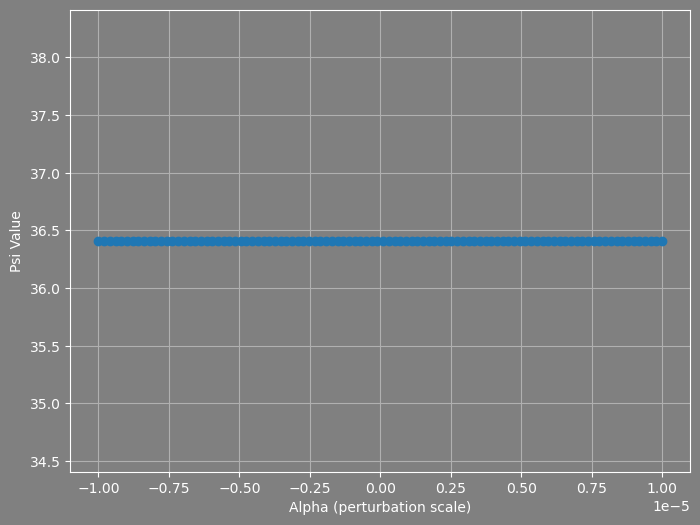

In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np
abs_eigenvalues = torch.abs(eigenvalues_final)
min_index = torch.argmin(abs_eigenvalues)
min_eigenvalue = eigenvalues_final[min_index].item()
min_eigenvector = eigenvectors_final[:, min_index]

print(f"Smallest absolute eigenvalue: {min_eigenvalue}")
print("Eigenvector corresponding to smallest eigenvalue:")
print(min_eigenvector.detach().numpy())

#  alpha range for perturbations
num_points = 100
alpha_range = np.linspace(-1e-5, 1e-5, num_points) 

Psi_values = []

# a wrapper for Psi_torch
def Psi_wrapper(p):
    return Psi_torch(p, x_torch, mu_W_shape, mu_Z_shape, k, Lambda_torch, tau, n, d)

with torch.no_grad():
    for alpha in alpha_range:
        perturbed_params = params_torch + alpha * min_eigenvector
        val = Psi_wrapper(perturbed_params)
        Psi_values.append(val.item())

plt.figure(figsize=(8, 6), facecolor='gray')  
plt.plot(alpha_range, Psi_values, marker='o')
plt.xlabel('Alpha (perturbation scale)', color='white')
plt.ylabel('Psi Value', color='white')
plt.grid(True)


ax = plt.gca()  
ax.set_facecolor('gray')  
ax.tick_params(axis='x', colors='white')  
ax.tick_params(axis='y', colors='white')  
for spine in ax.spines.values():  
    spine.set_edgecolor('white')


#ax.set_xlim([(-0.95)*1e-5, 0.95*1e-5])  # Set x-axis limits
#ax.set_ylim([min(Psi_values) - 0.00001, max(Psi_values) + 0.00001])  # Set y-axis limits dynamically
#plt.savefig("Psi_plot_flat1.pdf", format='pdf', bbox_inches='tight', facecolor='gray')

plt.show()


Smallest absolute eigenvalue: -6.849769097197131e-15
Eigenvector corresponding to smallest eigenvalue:
[ 0.10158794 -0.19962496  0.15944975 -0.07692838  0.22509611 -0.20156337
 -0.47814947  0.13951221  0.07920783 -0.09271606 -0.10537541  0.41953138
 -0.05009391  0.2107607   0.11467181 -0.11467181  0.00242101  0.38516414
 -0.38516414  0.08475163]


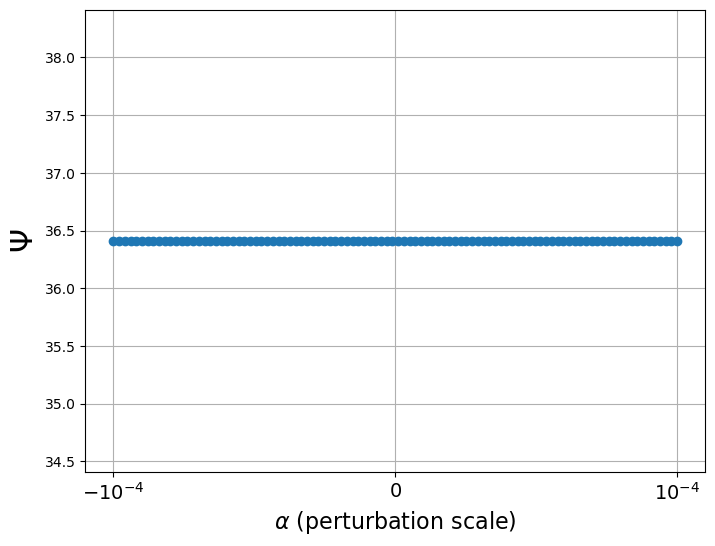

In [79]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Identify the eigenvector with the smallest absolute eigenvalue
abs_eigenvalues = torch.abs(eigenvalues_final)
min_index = torch.argmin(abs_eigenvalues)
min_eigenvalue = eigenvalues_final[min_index].item()
min_eigenvector = eigenvectors_final[:, min_index]

print(f"Smallest absolute eigenvalue: {min_eigenvalue}")
print("Eigenvector corresponding to smallest eigenvalue:")
print(min_eigenvector.detach().numpy())

# Alpha range for perturbations
num_points = 100
alpha_range = np.linspace(-1e-4, 1e-4, num_points) 

Psi_values = []

# Wrapper for Psi_torch
def Psi_wrapper(p):
    return Psi_torch(p, x_torch, mu_W_shape, mu_Z_shape, k, Lambda_torch, tau, n, d)

with torch.no_grad():
    for alpha in alpha_range:
        perturbed_params = params_torch + alpha * min_eigenvector
        val = Psi_wrapper(perturbed_params)
        Psi_values.append(val.item())


plt.style.use('default')

plt.figure(figsize=(8, 6))
plt.plot(alpha_range, Psi_values, marker='o')

# Set x-ticks to only show -10^-4, 0, and 10^-4
plt.xticks([-1e-4, 0, 1e-4], [r'$-10^{-4}$', r'$0$', r'$10^{-4}$'], fontsize=14)

# Adjust font sizes for axis labels
plt.xlabel(r'$\alpha$ (perturbation scale)', fontsize=16)
plt.ylabel(r'$\Psi$', fontsize=22)

plt.grid(True)

# Save the plot as a PDF
#plt.savefig("Psi_vs_alpha_k1_1.pdf", format="pdf")

plt.show()


Smallest absolute eigenvalue: -6.849769097197131e-15
Eigenvector corresponding to smallest eigenvalue:
[ 0.10158794 -0.19962496  0.15944975 -0.07692838  0.22509611 -0.20156337
 -0.47814947  0.13951221  0.07920783 -0.09271606 -0.10537541  0.41953138
 -0.05009391  0.2107607   0.11467181 -0.11467181  0.00242101  0.38516414
 -0.38516414  0.08475163]


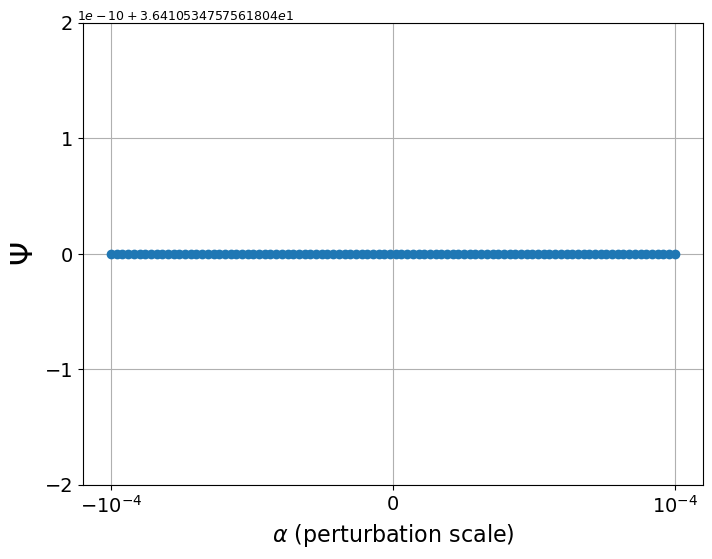

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# Identify the eigenvector with the smallest absolute eigenvalue
abs_eigenvalues = torch.abs(eigenvalues_final)
min_index = torch.argmin(abs_eigenvalues)
min_eigenvalue = eigenvalues_final[min_index].item()
min_eigenvector = eigenvectors_final[:, min_index]

print(f"Smallest absolute eigenvalue: {min_eigenvalue}")
print("Eigenvector corresponding to smallest eigenvalue:")
print(min_eigenvector.detach().numpy())

# Alpha range for perturbations
num_points = 100
alpha_range = np.linspace(-1e-4, 1e-4, num_points) 

Psi_values = []

# Wrapper for Psi_torch
def Psi_wrapper(p):
    return Psi_torch(p, x_torch, mu_W_shape, mu_Z_shape, k, Lambda_torch, tau, n, d)

with torch.no_grad():
    for alpha in alpha_range:
        perturbed_params = params_torch + alpha * min_eigenvector
        val = Psi_wrapper(perturbed_params)
        Psi_values.append(val.item())

# Define the baseline
baseline = 36.410534757461804

# Transform the Psi_values:
# Subtract the baseline so that the baseline will correspond to zero,
# then scale by 1e-10 so that the deviations are in units of 1e-10.
Psi_scaled = (np.array(Psi_values) - baseline) / (1e-10)

# Use default style (with white background)
plt.style.use('default')

plt.figure(figsize=(8, 6))
plt.plot(alpha_range, Psi_scaled, marker='o')

# Set x-ticks to only show -1e-4, 0, and 1e-4
plt.xticks([-1e-4, 0, 1e-4], [r'$-10^{-4}$', r'$0$', r'$10^{-4}$'], fontsize=14)

# Set y-ticks to display -2, -1, 0, 1, 2 (these are the scaled deviations)
plt.yticks([-2, -1, 0, 1, 2], fontsize=14)

# Adjust axis labels with appropriate font sizes
plt.xlabel(r'$\alpha$ (perturbation scale)', fontsize=16)
plt.ylabel(r'$ \Psi\ $', fontsize=22)

plt.grid(True)

# Add an annotation in the top left of the plot to indicate the offset.
# This text shows that the true values equal (1e-10 * [deviation]) + 3.6410534757561804e1.
ax = plt.gca()
ax.text(-0.01, 1.00, r'$1e-10+3.6410534757561804e1$', transform=ax.transAxes,
        fontsize=9, verticalalignment='bottom')
plt.savefig("Psi_vs_alpha_k2_24.pdf", format="pdf")

plt.show()


Smallest absolute eigenvalue: -6.849769097197131e-15
Eigenvector corresponding to smallest eigenvalue:
[ 0.10158794 -0.19962496  0.15944975 -0.07692838  0.22509611 -0.20156337
 -0.47814947  0.13951221  0.07920783 -0.09271606 -0.10537541  0.41953138
 -0.05009391  0.2107607   0.11467181 -0.11467181  0.00242101  0.38516414
 -0.38516414  0.08475163]


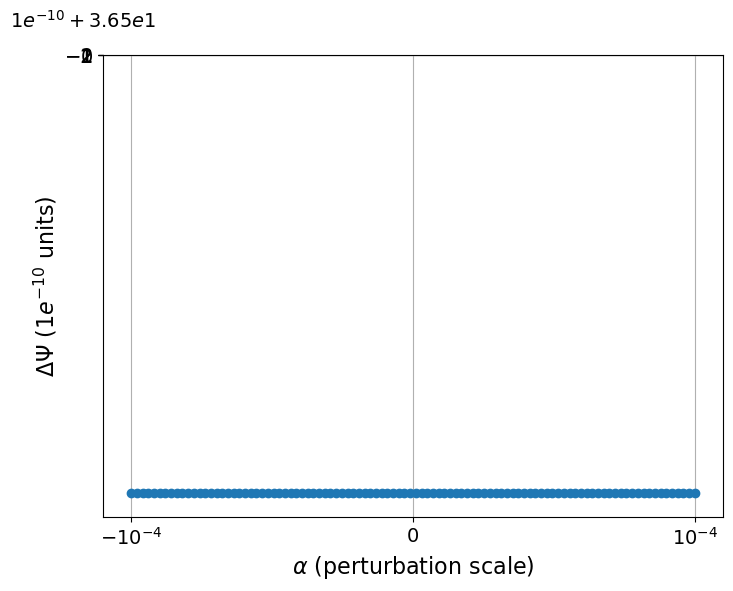

In [27]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Identify the eigenvector with the smallest absolute eigenvalue
abs_eigenvalues = torch.abs(eigenvalues_final)
min_index = torch.argmin(abs_eigenvalues)
min_eigenvalue = eigenvalues_final[min_index].item()
min_eigenvector = eigenvectors_final[:, min_index]

print(f"Smallest absolute eigenvalue: {min_eigenvalue}")
print("Eigenvector corresponding to smallest eigenvalue:")
print(min_eigenvector.detach().numpy())

# Alpha range for perturbations
num_points = 100
alpha_range = np.linspace(-1e-4, 1e-4, num_points)

Psi_values = []

# Wrapper for Psi_torch
def Psi_wrapper(p):
    return Psi_torch(p, x_torch, mu_W_shape, mu_Z_shape, k, Lambda_torch, tau, n, d)

with torch.no_grad():
    for alpha in alpha_range:
        perturbed_params = params_torch + alpha * min_eigenvector
        val = Psi_wrapper(perturbed_params)
        Psi_values.append(val.item())

# Assume the base value is 3.65e1 (i.e. 36.5)
base = 36.5

# Subtract the base value and scale the small variation by 1e-10
# This transformation reveals the tiny deviations in units of 1e-10.
Psi_scaled = (np.array(Psi_values) - base) / (1e-10)

# Use default style (white background)
plt.style.use('default')
plt.figure(figsize=(8, 6))

# Plot the transformed data
plt.plot(alpha_range, Psi_scaled, marker='o')

# Set x-ticks to show -1e-4, 0, and 1e-4
plt.xticks([-1e-4, 0, 1e-4], [r'$-10^{-4}$', r'$0$', r'$10^{-4}$'], fontsize=14)
# Set y-ticks as -2, -1, 0, 1, 2
plt.yticks([-2, -1, 0, 1, 2], fontsize=14)

# Adjust the labels. The ylabel here indicates that we are plotting 
# the deviation in units of 1e-10.
plt.xlabel(r'$\alpha$ (perturbation scale)', fontsize=16)
plt.ylabel(r'$\Delta \Psi\ (1e^{-10}\ \mathrm{units})$', fontsize=16)

plt.grid(True)

# Add an annotation on the top left of the axis to indicate the offset:
# This text shows that the true value is (1e-10 + 3.65e1).
ax = plt.gca()
ax.text(-0.15, 1.05, r'$1e^{-10} + 3.65e1$', transform=ax.transAxes,
        fontsize=14, verticalalignment='bottom')

plt.show()


In [61]:
Psi_values

[36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757461804,
 36.410534757

In [29]:
import numpy as np
import autograd.numpy as anp
from autograd import hessian

n, d, k, tau = 4, 3, 2, 100
diagonal_elements = [1, 1]
Lambda = np.diag(diagonal_elements)

W = np.ones((d, k))
W[0, 0] = 4

np.random.seed(1013)
z = np.random.normal(0, 1, size=(n, k))

x0 = np.dot(W, z.T)
mean = np.zeros(d)
cov = (1 / tau) * np.eye(d)
E = np.random.multivariate_normal(mean, cov, size=n).T
x = x0 + E

# initial values
mu_W = np.full((d, k), 0.1)
sigma_W = np.eye(k)
mu_z = np.full((n, k), 0.1)
sigma_z = np.eye(k)
x_size = np.linalg.norm(x)

# ============================================================
# CAVI recurrence
# ============================================================
def recurrence_iteration(mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k):
    increment = 50
    while increment > 1e-13:
        # Update sigma_W
        sigma_W_inv = tau * (mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z)) + Lambda
        sigma_W = np.linalg.inv(sigma_W_inv)

        # Update mu_W
        mu_W = tau * np.dot(np.dot(x, mu_z), sigma_W)

        # Update sigma_z
        sigma_z_inv = tau * (mu_W.shape[0] * sigma_W + np.dot(mu_W.T, mu_W)) + np.eye(k)
        sigma_z = np.linalg.inv(sigma_z_inv)

        # Update mu_z
        mu_z = tau * np.dot(np.dot(x.T, mu_W), sigma_z)

        # Compute ELBO
        B = (mu_W.shape[0] * sigma_W + np.dot(mu_W.T, mu_W)).dot(
            mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z)
        )
        C = d * np.trace(Lambda.dot(sigma_W)) + np.trace(mu_W.dot(Lambda).dot(mu_W.T))
        D = np.trace(mu_z.shape[0] * sigma_z + np.dot(mu_z.T, mu_z))
        sign_W, logdet_W = np.linalg.slogdet(sigma_W)
        sign_z, logdet_z = np.linalg.slogdet(sigma_z)

        if sign_W <= 0 or sign_z <= 0:
            raise ValueError("Determinants must be positive for PSD matrices.")

        ELBO = (
            tau * np.trace(mu_W.dot(mu_z.T).dot(x.T))
            - (tau / 2) * np.trace(B)
            - 0.5 * C
            - 0.5 * D
            + 0.5 * d * logdet_W
            + 0.5 * n * logdet_z
        )
        ELBOS.append(ELBO)

        # convergence
        if len(ELBOS) >= 2:
            increment = abs((ELBOS[-1] - ELBOS[-2]) / ELBOS[-2])

    return mu_W, sigma_W, mu_z, sigma_z, ELBOS

# run CAVI
ELBOS = []
mu_W, sigma_W, mu_z, sigma_z, ELBOS = recurrence_iteration(
    mu_W, sigma_W, mu_z, sigma_z, Lambda, ELBOS, x, tau, d, n, k
)

# ============================================================
# Angle calculations
# ============================================================
def angle_deg(v1, v2):
    v1 = np.asarray(v1).reshape(-1)
    v2 = np.asarray(v2).reshape(-1)

    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)

    if n1 == 0 or n2 == 0:
        raise ValueError("Angle undefined for zero vector.")

    cos_theta = np.dot(v1, v2) / (n1 * n2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))

# angle between columns of mu_W
print("Angles between columns of mu_W:")
for i in range(k):
    for j in range(i + 1, k):
        print(f"angle(mu_W[:, {i}], mu_W[:, {j}]) = {angle_deg(mu_W[:, i], mu_W[:, j]):.6f} degrees")

# angle between columns of mu_z
print("\nAngles between columns of mu_z:")
for i in range(k):
    for j in range(i + 1, k):
        print(f"angle(mu_z[:, {i}], mu_z[:, {j}]) = {angle_deg(mu_z[:, i], mu_z[:, j]):.6f} degrees")

Angles between columns of mu_W:
angle(mu_W[:, 0], mu_W[:, 1]) = 36.475454 degrees

Angles between columns of mu_z:
angle(mu_z[:, 0], mu_z[:, 1]) = 56.621376 degrees
